# Notebook 2 - Trust Region Methods

## Introduction

Where Newton's Method takes the step that exactly minimizes its local quadratic model, trust region methods ask a more cautious question: how far should we trust that model? By constraining each step to a ball of radius $\Delta_k$ around the current iterate, trust region methods gain three properties Newton's lacks by design — guaranteed descent, adaptive step scaling, and natural handling of indefinite Hessians.

This notebook implements the trust region framework applied to the **Beale function**, the same ill-conditioned benchmark used in Notebook 1. We compare convergence behavior, accepted vs. rejected steps, and the evolution of the trust region radius $\Delta_k$ — highlighting exactly where the trust region's safeguards intervene where Newton's Method would otherwise fail.

## Background

### Trust Region Methods

Trust region methods address Newton's weaknesses by restricting each step to a region where the quadratic model is trusted to be a good approximation of $f$. The subproblem solved at each iteration is:

$$\min_{p \in \mathbb{R}^n} \quad m_k(p) = f(x_k) + g_k^\top p + \frac{1}{2} p^\top B_k \, p$$
$$\text{subject to} \quad \|p\| \leq \Delta_k$$

where $g_k = \nabla f(x_k)$, $B_k$ is the Hessian (or an approximation), and $\Delta_k > 0$ is the trust region radius.

The radius is updated based on the **reduction ratio**:

$$\rho_k = \frac{f(x_k) - f(x_k + p_k)}{m_k(0) - m_k(p_k)}$$

which compares actual function decrease to the decrease predicted by the model. If $\rho_k \approx 1$ the model is accurate and $\Delta_k$ is expanded; if $\rho_k$ is small or negative the step is rejected and $\Delta_k$ is contracted.

**Strengths:**
- Globally convergent under mild assumptions, even from poor starting points
- Handles indefinite Hessians naturally — the constraint regularizes the subproblem
- Radius adaptation provides automatic step length control without a separate line search
- Can recover from regions where the quadratic model is poor

**Weaknesses:**
- The trust region subproblem requires an inner solver, adding per-iteration complexity
- Overhead per iteration is higher than a plain Newton step
- Convergence rate near a solution matches Newton's, but the constant may be worse

## Implementation

To implement this algorithm we will define a few arguments that will be used to implement **Trust Region Methods**.

---

### Objective Function

We reuse the Beale function and its gradient and Hessian derived in Notebook 1:

$$f(x, y) = r_1^2 + r_2^2 + r_3^2, \quad r_i = c_i - x + xy^i$$

where $c_1 = 1.5$, $c_2 = 2.25$, $c_3 = 2.625$ and the global minimizer is $(x^*, y^*) = (3, 0.5)$.

---

### Trust Region Subproblem

At each iterate $(x_k, y_k)$ we solve:

$$\min_{p \in \mathbb{R}^2} \quad m_k(p) = f(x_k, y_k) + g_k^\top p + \frac{1}{2} p^\top H_k \, p$$
$$\text{subject to} \quad \|p\| \leq \Delta_k$$

The exact solution satisfies the secular equation:

$$(H_k + \lambda I)\, p^* = -g_k, \quad \lambda \geq 0, \quad \lambda(\Delta_k - \|p^*\|) = 0$$

When $H_k$ is positive definite and $\|p_{\text{Newton}}\| \leq \Delta_k$, then $\lambda = 0$ and the trust region step coincides with the Newton step. Otherwise, $\lambda > 0$ shifts the Hessian to enforce the constraint.

---

### Radius Update Rule

After computing $p_k$ we evaluate the reduction ratio:

$$\rho_k = \frac{f(x_k) - f(x_k + p_k)}{m_k(0) - m_k(p_k)}$$

and update $\Delta_k$ according to:

$$\Delta_{k+1} = \begin{cases} \min(2\Delta_k, \Delta_{\max}) & \text{if } \rho_k > 0.75 \\ \Delta_k & \text{if } 0.25 \leq \rho_k \leq 0.75 \\ \frac{1}{4}\Delta_k & \text{if } \rho_k < 0.25 \end{cases}$$

Steps with $\rho_k < \eta = 0.1$ are **rejected** — the iterate does not move, only $\Delta_k$ shrinks.

---

### Dogleg Subproblem Solver

We use the **dogleg method** to solve the subproblem approximately. It interpolates between two anchor points:

- **Cauchy point** $p^C$: the steepest descent step clipped to the trust region boundary

$$p^C = -\frac{g_k^\top g_k}{g_k^\top H_k g_k} \cdot g_k \quad (\text{then clip to } \Delta_k)$$

- **Newton point** $p^N$: the unconstrained Newton step $p^N = -H_k^{-1} g_k$

The dogleg path follows $p^C$ then turns toward $p^N$, stopping at $\|p\| = \Delta_k$ if the Newton point lies outside. This requires $H_k$ to be positive definite; otherwise the method falls back to the Cauchy point.

## Code

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from utilities import beale

In [4]:
def beale_f(x, y):
    """
    Evaluate the Beale function at a point (x, y).

    Args:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        float: Function value f(x, y).
    """
    r1 = 1.5   - x + x * y
    r2 = 2.25  - x + x * y**2
    r3 = 2.625 - x + x * y**3
    return r1**2 + r2**2 + r3**2


def beale_grad(x, y):
    """
    Compute the gradient of the Beale function at (x, y).

    Args:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        np.ndarray: Gradient vector [df/dx, df/dy].
    """
    r1 = 1.5   - x + x * y
    r2 = 2.25  - x + x * y**2
    r3 = 2.625 - x + x * y**3

    df_dx = 2*r1*(y - 1) + 2*r2*(y**2 - 1) + 2*r3*(y**3 - 1)
    df_dy = 2*r1*x       + 4*r2*x*y         + 6*r3*x*y**2
    return np.array([df_dx, df_dy])


def beale_hess(x, y):
    """
    Compute the Hessian of the Beale function at (x, y).

    Args:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        np.ndarray: 2x2 Hessian matrix.
    """
    r1 = 1.5   - x + x * y
    r2 = 2.25  - x + x * y**2
    r3 = 2.625 - x + x * y**3

    H_xx = 2*(y - 1)**2 + 2*(y**2 - 1)**2 + 2*(y**3 - 1)**2
    H_yy = 2*x**2 + 4*r2*x + 8*x**2*y**2 + 12*r3*x*y + 18*x**2*y**4
    H_xy = (2*r1 + 4*r2*y + 6*r3*y**2
            + 2*x*(y - 1) + 4*x*y*(y**2 - 1) + 6*x*y**2*(y**3 - 1))

    return np.array([[H_xx, H_xy],
                     [H_xy, H_yy]])

In [5]:
def dogleg_step(gk, Hk, delta):
    """
    Compute the dogleg step for the trust region subproblem.

    Strategy:
        1. Compute the Cauchy point p_C (steepest descent, clipped to delta)
        2. If H_k is positive definite, compute the Newton point p_N
        3. If ||p_N|| <= delta: return Newton step
        4. Otherwise: interpolate along the dogleg path to the boundary

    Args:
        gk    (np.ndarray): Gradient vector at current iterate.
        Hk    (np.ndarray): Hessian matrix at current iterate.
        delta (float):      Trust region radius.

    Returns:
        np.ndarray: Step vector p.
    """
    # Cauchy point
    gHg = gk @ Hk @ gk
    if gHg <= 0:
        # Negative curvature — move to boundary along steepest descent
        return -delta * gk / np.linalg.norm(gk)

    alpha_c = (gk @ gk) / gHg
    p_C     = -alpha_c * gk
    if np.linalg.norm(p_C) >= delta:
        return delta * p_C / np.linalg.norm(p_C)

    # Newton point (requires H_k positive definite)
    eigvals = np.linalg.eigvalsh(Hk)
    if np.all(eigvals > 0):
        p_N = np.linalg.solve(Hk, -gk)
        if np.linalg.norm(p_N) <= delta:
            return p_N

        # Interpolate along dogleg path: p_C -> p_N, find boundary crossing
        d   = p_N - p_C
        a   = d @ d
        b   = 2 * (p_C @ d)
        c   = (p_C @ p_C) - delta**2
        tau = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
        tau = np.clip(tau, 0, 1)
        return p_C + tau * d

    # Fallback: return Cauchy point
    return p_C

In [6]:
def trust_region(x0, y0, delta0=1.0, delta_max=5.0, eta=0.1, tol=1e-6, max_iter=200):
    """
    Trust Region Method (Dogleg) for minimizing the Beale function.

    At each iteration:
        1. Compute gradient g_k and Hessian H_k
        2. Check convergence: ||g_k|| < tol
        3. Solve the trust region subproblem via dogleg
        4. Compute the reduction ratio rho_k
        5. Accept or reject the step based on rho_k >= eta
        6. Update the trust region radius delta_k

    Args:
        x0        (float): Initial x-coordinate.
        y0        (float): Initial y-coordinate.
        delta0    (float): Initial trust region radius.
        delta_max (float): Maximum trust region radius.
        eta       (float): Minimum acceptable reduction ratio.
        tol       (float): Gradient norm convergence tolerance.
        max_iter  (int):   Maximum number of iterations.

    Returns:
        dict: {
            'path'       : list of (x, y) iterates,
            'f_vals'     : list of function values,
            'grad_norms' : list of gradient norms,
            'rho_vals'   : list of reduction ratios,
            'delta_vals' : list of trust region radii,
            'accepted'   : list of bools (step accepted?),
            'converged'  : bool
        }
    """
    xk, yk     = x0, y0
    delta      = delta0
    path       = [(xk, yk)]
    f_vals     = [beale_f(xk, yk)]
    grad_norms = []
    rho_vals   = []
    delta_vals = [delta]
    accepted   = []
    converged  = False

    for k in range(max_iter):
        gk = beale_grad(xk, yk)
        Hk = beale_hess(xk, yk)

        grad_norm = np.linalg.norm(gk)
        grad_norms.append(grad_norm)

        if grad_norm < tol:
            converged = True
            print(f"Converged at iteration {k}  |  f = {beale_f(xk, yk):.2e}  |  ||g|| = {grad_norm:.2e}")
            break

        # Solve trust region subproblem
        pk = dogleg_step(gk, Hk, delta)

        # Reduction ratio
        fk        = beale_f(xk, yk)
        f_new     = beale_f(xk + pk[0], yk + pk[1])
        m_decrease = -(gk @ pk + 0.5 * pk @ Hk @ pk)   # m_k(0) - m_k(p_k)

        if abs(m_decrease) < 1e-14:
            rho = 0.0
        else:
            rho = (fk - f_new) / m_decrease

        rho_vals.append(rho)

        # Step acceptance
        step_accepted = rho >= eta
        accepted.append(step_accepted)

        if step_accepted:
            xk += pk[0]
            yk += pk[1]

        # Radius update
        if rho > 0.75:
            delta = min(2 * delta, delta_max)
        elif rho < 0.25:
            delta = delta / 4

        path.append((xk, yk))
        f_vals.append(beale_f(xk, yk))
        delta_vals.append(delta)

    if not converged:
        print(f"Did not converge within {max_iter} iterations.")

    return {
        'path'       : path,
        'f_vals'     : f_vals,
        'grad_norms' : grad_norms,
        'rho_vals'   : rho_vals,
        'delta_vals' : delta_vals,
        'accepted'   : accepted,
        'converged'  : converged
    }

In [7]:
# Run Trust Region from two starting points
result_near = trust_region(x0=2.0,  y0=0.4,  delta0=1.0, max_iter=200)  # near minimizer
result_far  = trust_region(x0=-2.0, y0=3.0,  delta0=1.0, max_iter=200)  # far from minimizer

Converged at iteration 9  |  f = 2.96e-24  |  ||g|| = 4.69e-12
Did not converge within 200 iterations.


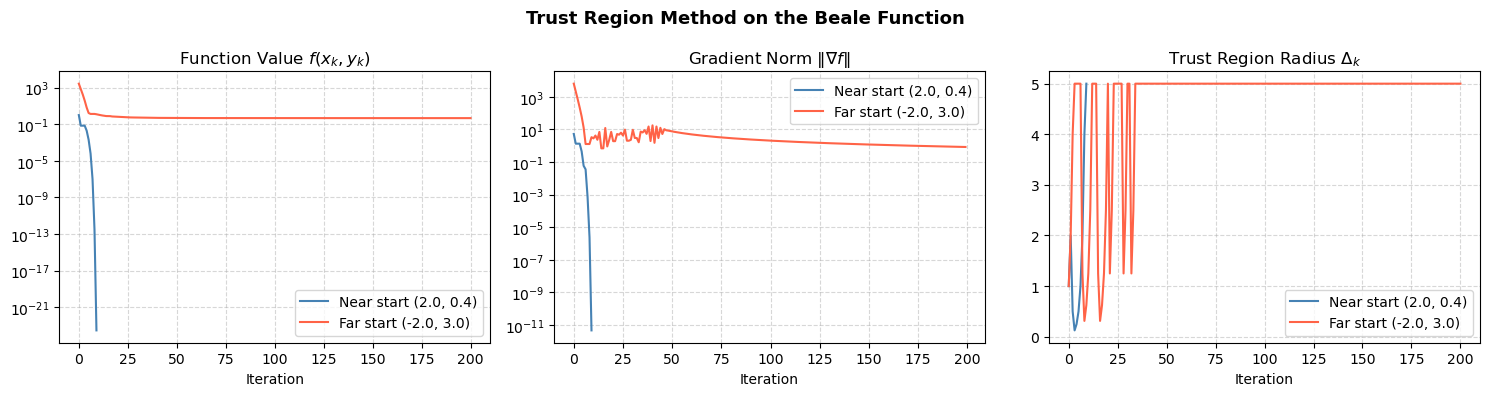

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for result, label, color in [
    (result_near, 'Near start (2.0, 0.4)',  'steelblue'),
    (result_far,  'Far start (-2.0, 3.0)', 'tomato')
]:
    axes[0].semilogy(range(len(result['f_vals'])),     result['f_vals'],     label=label, color=color)
    axes[1].semilogy(range(len(result['grad_norms'])), result['grad_norms'], label=label, color=color)
    axes[2].plot(range(len(result['delta_vals'])),     result['delta_vals'], label=label, color=color)

axes[0].set_title('Function Value $f(x_k, y_k)$');      axes[0].set_xlabel('Iteration')
axes[1].set_title('Gradient Norm $\\|\\nabla f\\|$');     axes[1].set_xlabel('Iteration')
axes[2].set_title('Trust Region Radius $\\Delta_k$');    axes[2].set_xlabel('Iteration')

for ax in axes:
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.suptitle('Trust Region Method on the Beale Function', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

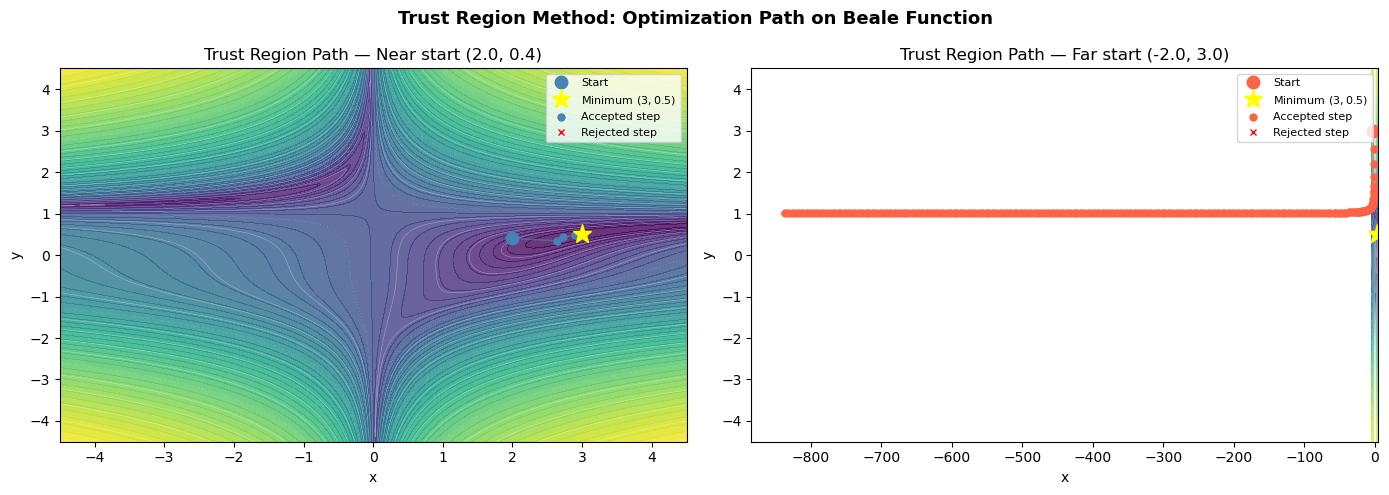

In [9]:
# Contour plot with optimization path and accepted/rejected markers
x_grid = np.linspace(-4.5, 4.5, 400)
y_grid = np.linspace(-4.5, 4.5, 400)
X, Y   = np.meshgrid(x_grid, y_grid)
Z      = beale_f(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, label, color in [
    (axes[0], result_near, 'Near start (2.0, 0.4)',  'steelblue'),
    (axes[1], result_far,  'Far start (-2.0, 3.0)', 'tomato')
]:
    ax.contourf(X, Y, np.log1p(Z), levels=50, cmap='viridis', alpha=0.8)
    ax.contour(X,  Y, np.log1p(Z), levels=20, colors='white', linewidths=0.4, alpha=0.4)

    xs, ys   = zip(*result['path'])
    accepted = result['accepted']

    ax.plot(xs, ys, '-', color=color, linewidth=1.2, alpha=0.6)

    for i, (x, y, acc) in enumerate(zip(xs[:-1], ys[:-1], accepted)):
        marker = 'o' if acc else 'x'
        mcolor = color if acc else 'red'
        ax.plot(x, y, marker, color=mcolor, markersize=5)

    ax.plot(xs[0], ys[0], 'o', color=color, markersize=9, label='Start')
    ax.plot(3, 0.5, '*', color='yellow', markersize=14, label='Minimum $(3, 0.5)$')
    ax.plot([], [], 'o', color=color, markersize=5, label='Accepted step')
    ax.plot([], [], 'x', color='red',   markersize=5, label='Rejected step')

    ax.set_title(f'Trust Region Path — {label}')
    ax.set_xlabel('x');  ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('Trust Region Method: Optimization Path on Beale Function', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

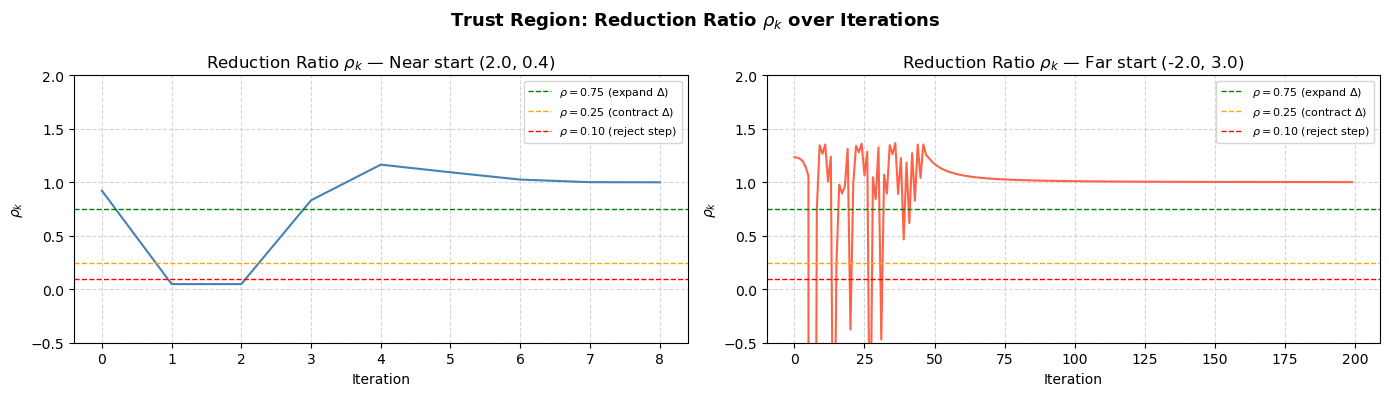

In [10]:
# Reduction ratio rho_k over iterations — shows where model was trusted vs. contracted
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, result, label, color in [
    (axes[0], result_near, 'Near start (2.0, 0.4)',  'steelblue'),
    (axes[1], result_far,  'Far start (-2.0, 3.0)', 'tomato')
]:
    rhos = result['rho_vals']
    ax.plot(rhos, color=color, linewidth=1.5)
    ax.axhline(0.75, color='green', linestyle='--', linewidth=1, label='$\\rho = 0.75$ (expand $\\Delta$)')
    ax.axhline(0.25, color='orange', linestyle='--', linewidth=1, label='$\\rho = 0.25$ (contract $\\Delta$)')
    ax.axhline(0.10, color='red',    linestyle='--', linewidth=1, label='$\\rho = 0.10$ (reject step)')
    ax.set_title(f'Reduction Ratio $\\rho_k$ — {label}')
    ax.set_xlabel('Iteration');  ax.set_ylabel('$\\rho_k$')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(-0.5, 2.0)

plt.suptitle('Trust Region: Reduction Ratio $\\rho_k$ over Iterations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()